In [213]:
import pandas as pd
import numpy as np
from scipy import odr

In [214]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty


In [215]:
import matplotlib.pyplot as plt

counts_df = pd.read_csv("counts.csv")
centroids_df = pd.read_csv("centroids.csv")
fwhms_df = pd.read_csv("fwhms.csv")
thicknesses_df = pd.read_csv("thicknesses.csv")

pb_thicknesses = np.concatenate([[0], thicknesses_df["pb"].values])
al_thicknesses = np.concatenate([[0], thicknesses_df["al"].values])

pb_cumulative = np.cumsum(pb_thicknesses)
al_cumulative = np.cumsum(al_thicknesses)

pb_thickness_unc_individual = 0.1
al_thickness_unc_individual = 0.1

pb_cumulative_unc = np.array(
    [max(0.01, i * pb_thickness_unc_individual) for i in range(len(pb_cumulative))]
)
al_cumulative_unc = np.array(
    [max(0.01, i * al_thickness_unc_individual) for i in range(len(al_cumulative))]
)

pb_peak1 = counts_df["pb_peak1"].values
pb_peak2 = counts_df["pb_peak2"].values
al_peak1 = counts_df["al_peak1"].values
al_peak2 = counts_df["al_peak2"].values

pb_peak1_unc = np.sqrt(pb_peak1)
pb_peak2_unc = np.sqrt(pb_peak2)
al_peak1_unc = np.sqrt(al_peak1)
al_peak2_unc = np.sqrt(al_peak2)

pb_centroid1 = centroids_df["pb_mode1"].values
pb_centroid2 = centroids_df["pb_mode2"].values
al_centroid1 = centroids_df["al_mode1"].values
al_centroid2 = centroids_df["al_mode2"].values

pb_fwhm1 = fwhms_df["pb_fwhm1"].values
pb_fwhm2 = fwhms_df["pb_fwhm2"].values
al_fwhm1 = fwhms_df["al_fwhm1"].values
al_fwhm2 = fwhms_df["al_fwhm2"].values

pb_centroid1_unc = pb_fwhm1 / 2
pb_centroid2_unc = pb_fwhm2 / 2
al_centroid1_unc = al_fwhm1 / 2
al_centroid2_unc = al_fwhm2 / 2

rho_pb = 11340
rho_al = 2700


@misc{nudat_nndc,
title = {NuDat: Nuclear Data Lookup from the National Nuclear Data Center},
author = {{National Nuclear Data Center}},
howpublished = {\url{https://www.nndc.bnl.gov/nudat/}},
note = {Accessed: 2025-11-12},
year = 2025
}


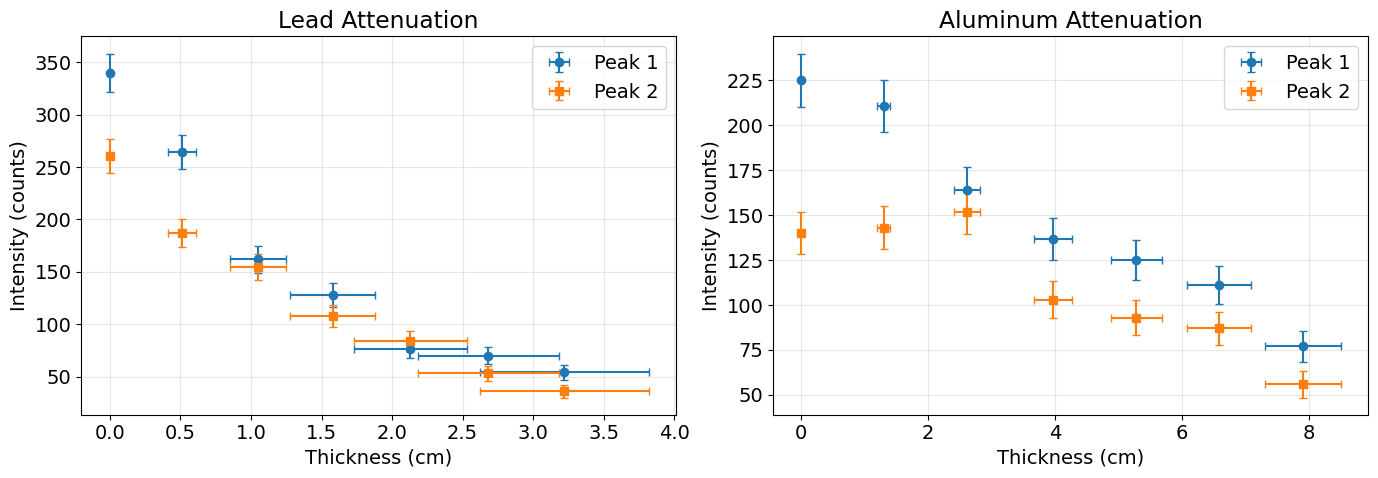

In [216]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].errorbar(
    pb_cumulative,
    pb_peak1,
    yerr=pb_peak1_unc,
    xerr=pb_cumulative_unc,
    fmt="o",
    label="Peak 1",
    capsize=3,
)
axes[0].errorbar(
    pb_cumulative,
    pb_peak2,
    yerr=pb_peak2_unc,
    xerr=pb_cumulative_unc,
    fmt="s",
    label="Peak 2",
    capsize=3,
)
axes[0].set_xlabel("Thickness (cm)")
axes[0].set_ylabel("Intensity (counts)")
axes[0].set_title("Lead Attenuation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].errorbar(
    al_cumulative,
    al_peak1,
    yerr=al_peak1_unc,
    xerr=al_cumulative_unc,
    fmt="o",
    label="Peak 1",
    capsize=3,
)
axes[1].errorbar(
    al_cumulative,
    al_peak2,
    yerr=al_peak2_unc,
    xerr=al_cumulative_unc,
    fmt="s",
    label="Peak 2",
    capsize=3,
)
axes[1].set_xlabel("Thickness (cm)")
axes[1].set_ylabel("Intensity (counts)")
axes[1].set_title("Aluminum Attenuation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [217]:
def weighted_linear_fit(x, y, x_unc, y_unc):
    """
    Linear fit using York method (via scipy's ODR)
    Handles uncertainties in both x and y.
    """

    def linear_func(p, x):
        return p[0] * x + p[1]

    linear_model = odr.Model(linear_func)
    data = odr.RealData(x, y, sx=x_unc, sy=y_unc)

    weights = 1 / y_unc**2
    slope_init = np.sum(weights * (x - np.mean(x)) * (y - np.mean(y))) / np.sum(
        weights * (x - np.mean(x)) ** 2
    )
    intercept_init = np.mean(y) - slope_init * np.mean(x)

    odr_obj = odr.ODR(data, linear_model, beta0=[slope_init, intercept_init])
    output = odr_obj.run()

    return output.beta[0], output.beta[1], output.sd_beta[0], output.sd_beta[1]


def ln_intensity_unc(intensity, intensity_unc):
    return intensity_unc / intensity


ln_pb_peak1 = np.log(pb_peak1)
ln_pb_peak2 = np.log(pb_peak2)
ln_al_peak1 = np.log(al_peak1)
ln_al_peak2 = np.log(al_peak2)

ln_pb_peak1_unc = ln_intensity_unc(pb_peak1, pb_peak1_unc)
ln_pb_peak2_unc = ln_intensity_unc(pb_peak2, pb_peak2_unc)
ln_al_peak1_unc = ln_intensity_unc(al_peak1, al_peak1_unc)
ln_al_peak2_unc = ln_intensity_unc(al_peak2, al_peak2_unc)

slope_pb1, intercept_pb1, slope_pb1_unc, intercept_pb1_unc = weighted_linear_fit(
    pb_cumulative, ln_pb_peak1, pb_cumulative_unc, ln_pb_peak1_unc
)
slope_pb2, intercept_pb2, slope_pb2_unc, intercept_pb2_unc = weighted_linear_fit(
    pb_cumulative, ln_pb_peak2, pb_cumulative_unc, ln_pb_peak2_unc
)
slope_al1, intercept_al1, slope_al1_unc, intercept_al1_unc = weighted_linear_fit(
    al_cumulative, ln_al_peak1, al_cumulative_unc, ln_al_peak1_unc
)
slope_al2, intercept_al2, slope_al2_unc, intercept_al2_unc = weighted_linear_fit(
    al_cumulative, ln_al_peak2, al_cumulative_unc, ln_al_peak2_unc
)

alpha_pb1 = -slope_pb1
alpha_pb2 = -slope_pb2
alpha_al1 = -slope_al1
alpha_al2 = -slope_al2

alpha_pb1_unc = slope_pb1_unc
alpha_pb2_unc = slope_pb2_unc
alpha_al1_unc = slope_al1_unc
alpha_al2_unc = slope_al2_unc

alpha_pb1_rounded, alpha_pb1_unc_rounded = round_unc(alpha_pb1, alpha_pb1_unc)
alpha_pb2_rounded, alpha_pb2_unc_rounded = round_unc(alpha_pb2, alpha_pb2_unc)
alpha_al1_rounded, alpha_al1_unc_rounded = round_unc(alpha_al1, alpha_al1_unc)
alpha_al2_rounded, alpha_al2_unc_rounded = round_unc(alpha_al2, alpha_al2_unc)

print(f"Lead Peak 1: α = ({alpha_pb1_rounded} ± {alpha_pb1_unc_rounded}) cm⁻¹")
print(f"Lead Peak 2: α = ({alpha_pb2_rounded} ± {alpha_pb2_unc_rounded}) cm⁻¹")
print(f"Aluminum Peak 1: α = ({alpha_al1_rounded} ± {alpha_al1_unc_rounded}) cm⁻¹")
print(f"Aluminum Peak 2: α = ({alpha_al2_rounded} ± {alpha_al2_unc_rounded}) cm⁻¹")


Lead Peak 1: α = (0.63 ± 0.04) cm⁻¹
Lead Peak 2: α = (0.572 ± 0.026) cm⁻¹
Aluminum Peak 1: α = (0.13 ± 0.01) cm⁻¹
Aluminum Peak 2: α = (0.105 ± 0.024) cm⁻¹


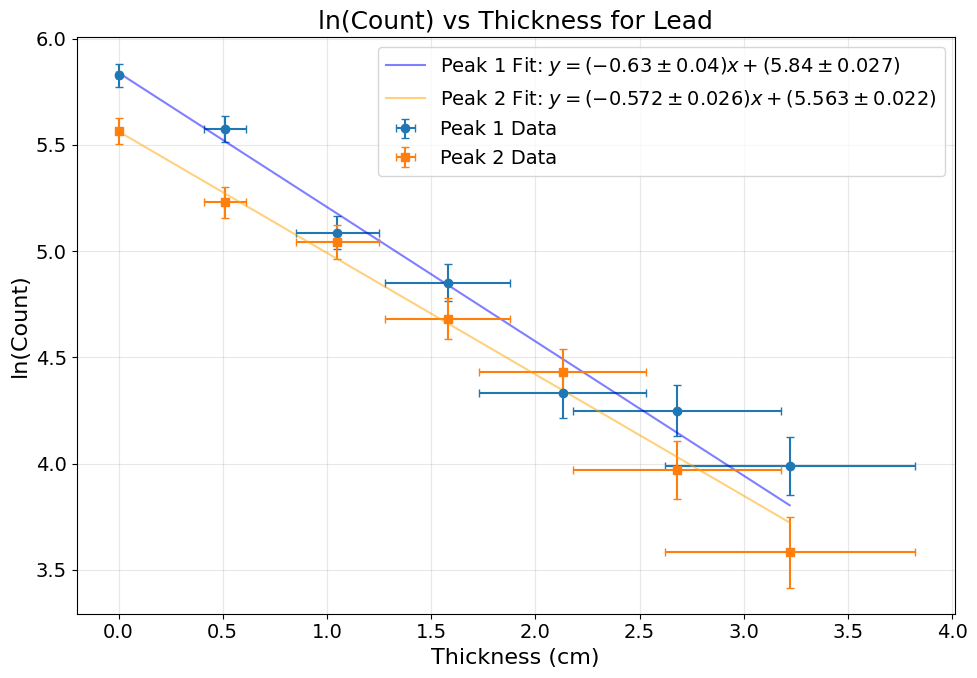

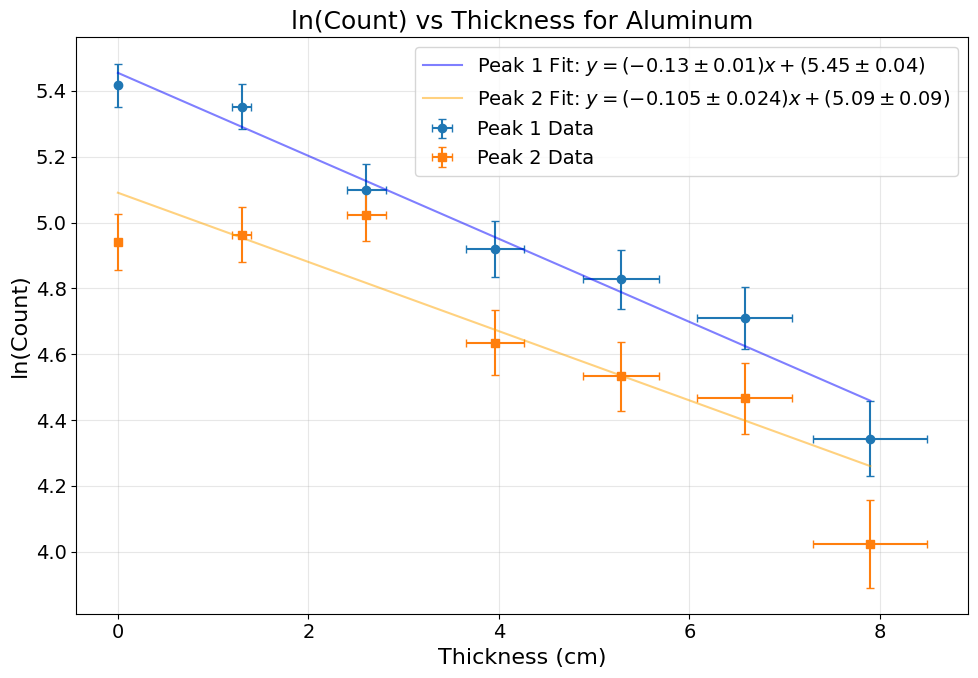

In [222]:
x_fit_pb = np.linspace(0, pb_cumulative[-1], 100)
x_fit_al = np.linspace(0, al_cumulative[-1], 100)

slope_pb1_r, slope_pb1_unc_r = round_unc(slope_pb1, slope_pb1_unc)
intercept_pb1_r, intercept_pb1_unc_r = round_unc(intercept_pb1, intercept_pb1_unc)
slope_pb2_r, slope_pb2_unc_r = round_unc(slope_pb2, slope_pb2_unc)
intercept_pb2_r, intercept_pb2_unc_r = round_unc(intercept_pb2, intercept_pb2_unc)

slope_al1_r, slope_al1_unc_r = round_unc(slope_al1, slope_al1_unc)
intercept_al1_r, intercept_al1_unc_r = round_unc(intercept_al1, intercept_al1_unc)
slope_al2_r, slope_al2_unc_r = round_unc(slope_al2, slope_al2_unc)
intercept_al2_r, intercept_al2_unc_r = round_unc(intercept_al2, intercept_al2_unc)

plt.rcParams.update({"font.size": 14})

fig1, ax1 = plt.subplots(figsize=(10, 7))
ax1.errorbar(
    pb_cumulative,
    ln_pb_peak1,
    yerr=ln_pb_peak1_unc,
    xerr=pb_cumulative_unc,
    fmt="o",
    label="Peak 1 Data",
    capsize=3,
)
ax1.plot(
    x_fit_pb,
    slope_pb1 * x_fit_pb + intercept_pb1,
    "b-",
    alpha=0.5,
    label=f"Peak 1 Fit: $y = ({slope_pb1_r} \\pm {slope_pb1_unc_r})x + ({intercept_pb1_r} \\pm {intercept_pb1_unc_r})$",
)
ax1.errorbar(
    pb_cumulative,
    ln_pb_peak2,
    yerr=ln_pb_peak2_unc,
    xerr=pb_cumulative_unc,
    fmt="s",
    label="Peak 2 Data",
    capsize=3,
)
ax1.plot(
    x_fit_pb,
    slope_pb2 * x_fit_pb + intercept_pb2,
    "orange",
    alpha=0.5,
    label=f"Peak 2 Fit: $y = ({slope_pb2_r} \\pm {slope_pb2_unc_r})x + ({intercept_pb2_r} \\pm {intercept_pb2_unc_r})$",
)
ax1.set_xlabel("Thickness (cm)", fontsize=16)
ax1.set_ylabel("ln(Count)", fontsize=16)
ax1.set_title("ln(Count) vs Thickness for Lead", fontsize=18)
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="both", labelsize=14)
plt.savefig("lead_attenuation.png")
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 7))
ax2.errorbar(
    al_cumulative,
    ln_al_peak1,
    yerr=ln_al_peak1_unc,
    xerr=al_cumulative_unc,
    fmt="o",
    label="Peak 1 Data",
    capsize=3,
)
ax2.plot(
    x_fit_al,
    slope_al1 * x_fit_al + intercept_al1,
    "b-",
    alpha=0.5,
    label=f"Peak 1 Fit: $y = ({slope_al1_r} \\pm {slope_al1_unc_r})x + ({intercept_al1_r} \\pm {intercept_al1_unc_r})$",
)
ax2.errorbar(
    al_cumulative,
    ln_al_peak2,
    yerr=ln_al_peak2_unc,
    xerr=al_cumulative_unc,
    fmt="s",
    label="Peak 2 Data",
    capsize=3,
)
ax2.plot(
    x_fit_al,
    slope_al2 * x_fit_al + intercept_al2,
    "orange",
    alpha=0.5,
    label=f"Peak 2 Fit: $y = ({slope_al2_r} \\pm {slope_al2_unc_r})x + ({intercept_al2_r} \\pm {intercept_al2_unc_r})$",
)
ax2.set_xlabel("Thickness (cm)", fontsize=16)
ax2.set_ylabel("ln(Count)", fontsize=16)
ax2.set_title("ln(Count) vs Thickness for Aluminum", fontsize=18)
ax2.legend(fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis="both", labelsize=14)

plt.tight_layout()
plt.savefig("aluminum_attenuation.png")
plt.show()


In [219]:
def mu_uncertainty(alpha, alpha_unc, rho):
    return alpha_unc / rho


alpha_pb1_si = alpha_pb1 * 100
alpha_pb2_si = alpha_pb2 * 100
alpha_al1_si = alpha_al1 * 100
alpha_al2_si = alpha_al2 * 100

alpha_pb1_unc_si = alpha_pb1_unc * 100
alpha_pb2_unc_si = alpha_pb2_unc * 100
alpha_al1_unc_si = alpha_al1_unc * 100
alpha_al2_unc_si = alpha_al2_unc * 100

mu_pb1 = alpha_pb1_si / rho_pb
mu_pb2 = alpha_pb2_si / rho_pb
mu_al1 = alpha_al1_si / rho_al
mu_al2 = alpha_al2_si / rho_al

mu_pb1_unc = mu_uncertainty(alpha_pb1_unc_si, alpha_pb1_unc_si, rho_pb)
mu_pb2_unc = mu_uncertainty(alpha_pb2_unc_si, alpha_pb2_unc_si, rho_pb)
mu_al1_unc = mu_uncertainty(alpha_al1_unc_si, alpha_al1_unc_si, rho_al)
mu_al2_unc = mu_uncertainty(alpha_al2_unc_si, alpha_al2_unc_si, rho_al)

mu_pb1_rounded, mu_pb1_unc_rounded = round_unc(mu_pb1, mu_pb1_unc)
mu_pb2_rounded, mu_pb2_unc_rounded = round_unc(mu_pb2, mu_pb2_unc)
mu_al1_rounded, mu_al1_unc_rounded = round_unc(mu_al1, mu_al1_unc)
mu_al2_rounded, mu_al2_unc_rounded = round_unc(mu_al2, mu_al2_unc)

print(f"Lead Peak 1: μ = ({mu_pb1_rounded} ± {mu_pb1_unc_rounded}) m²/kg")
print(f"Lead Peak 2: μ = ({mu_pb2_rounded} ± {mu_pb2_unc_rounded}) m²/kg")
print(f"Aluminum Peak 1: μ = ({mu_al1_rounded} ± {mu_al1_unc_rounded}) m²/kg")
print(f"Aluminum Peak 2: μ = ({mu_al2_rounded} ± {mu_al2_unc_rounded}) m²/kg")


Lead Peak 1: μ = (0.0056 ± 0.0003) m²/kg
Lead Peak 2: μ = (0.00504 ± 0.00023) m²/kg
Aluminum Peak 1: μ = (0.0047 ± 0.0004) m²/kg
Aluminum Peak 2: μ = (0.0039 ± 0.0009) m²/kg


In [220]:
def linear_interpolation(x, x1, y1, x2, y2):
    """
    Linearly interpolate to find y at x given points (x1, y1) and (x2, y2).

    Parameters:
    - x: the target x value to interpolate at
    - x1, y1: coordinates of the first point
    - x2, y2: coordinates of the second point

    Returns:
    - y: interpolated y value at x
    """
    return y1 + (x - x1) * (y2 - y1) / (x2 - x1)


E_peak1 = 1.1732
E_peak2 = 1.3325

mu_rho_pb_1p00 = 7.102e-02
mu_rho_pb_1p25 = 5.876e-02
mu_rho_pb_1p50 = 5.222e-02

mu_rho_al_1p00 = 6.146e-02
mu_rho_al_1p25 = 5.496e-02
mu_rho_al_1p50 = 5.006e-02

mu_rho_pb_peak1 = linear_interpolation(
    E_peak1, 1.00, mu_rho_pb_1p00, 1.25, mu_rho_pb_1p25
)
mu_rho_pb_peak2 = linear_interpolation(
    E_peak2, 1.25, mu_rho_pb_1p25, 1.50, mu_rho_pb_1p50
)

mu_rho_al_peak1 = linear_interpolation(
    E_peak1, 1.00, mu_rho_al_1p00, 1.25, mu_rho_al_1p25
)
mu_rho_al_peak2 = linear_interpolation(
    E_peak2, 1.25, mu_rho_al_1p25, 1.50, mu_rho_al_1p50
)

print("Theoretical Mass Attenuation Coefficients (μ/ρ):")
print(
    f"\nLead at {E_peak1} MeV (Peak 1): {mu_rho_pb_peak1:.6f} cm²/g = {mu_rho_pb_peak1 * 0.1:.6f} m²/kg"
)
print(
    f"Lead at {E_peak2} MeV (Peak 2): {mu_rho_pb_peak2:.6f} cm²/g = {mu_rho_pb_peak2 * 0.1:.6f} m²/kg"
)
print(
    f"\nAluminum at {E_peak1} MeV (Peak 1): {mu_rho_al_peak1:.6f} cm²/g = {mu_rho_al_peak1 * 0.1:.6f} m²/kg"
)
print(
    f"Aluminum at {E_peak2} MeV (Peak 2): {mu_rho_al_peak2:.6f} cm²/g = {mu_rho_al_peak2 * 0.1:.6f} m²/kg"
)

print("\n\nExperimental Mass Attenuation Coefficients (μ):")
print(f"\nLead at Peak 1: ({mu_pb1_rounded} ± {mu_pb1_unc_rounded}) m²/kg")
print(f"Lead at Peak 2: ({mu_pb2_rounded} ± {mu_pb2_unc_rounded}) m²/kg")
print(f"\nAluminum at Peak 1: ({mu_al1_rounded} ± {mu_al1_unc_rounded}) m²/kg")
print(f"Aluminum at Peak 2: ({mu_al2_rounded} ± {mu_al2_unc_rounded}) m²/kg")

mu_rho_pb_peak1_si = mu_rho_pb_peak1 * 0.1
mu_rho_pb_peak2_si = mu_rho_pb_peak2 * 0.1
mu_rho_al_peak1_si = mu_rho_al_peak1 * 0.1
mu_rho_al_peak2_si = mu_rho_al_peak2 * 0.1

discrepancy_pb1 = abs(mu_pb1 - mu_rho_pb_peak1_si)
discrepancy_pb2 = abs(mu_pb2 - mu_rho_pb_peak2_si)
discrepancy_al1 = abs(mu_al1 - mu_rho_al_peak1_si)
discrepancy_al2 = abs(mu_al2 - mu_rho_al_peak2_si)

n_sigma_pb1 = discrepancy_pb1 / mu_pb1_unc
n_sigma_pb2 = discrepancy_pb2 / mu_pb2_unc
n_sigma_al1 = discrepancy_al1 / mu_al1_unc
n_sigma_al2 = discrepancy_al2 / mu_al2_unc

print("\n\nComparison (Experimental vs Theoretical):")
print(f"\nLead Peak 1:")
print(f"  Ratio: {mu_pb1 / mu_rho_pb_peak1_si:.3f}")
print(f"  Discrepancy: {discrepancy_pb1:.6f} m²/kg ({n_sigma_pb1:.1f}σ)")

print(f"\nLead Peak 2:")
print(f"  Ratio: {mu_pb2 / mu_rho_pb_peak2_si:.3f}")
print(f"  Discrepancy: {discrepancy_pb2:.6f} m²/kg ({n_sigma_pb2:.1f}σ)")

print(f"\nAluminum Peak 1:")
print(f"  Ratio: {mu_al1 / mu_rho_al_peak1_si:.3f}")
print(f"  Discrepancy: {discrepancy_al1:.6f} m²/kg ({n_sigma_al1:.1f}σ)")

print(f"\nAluminum Peak 2:")
print(f"  Ratio: {mu_al2 / mu_rho_al_peak2_si:.3f}")
print(f"  Discrepancy: {discrepancy_al2:.6f} m²/kg ({n_sigma_al2:.1f}σ)")

print("\n\n")
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\caption{Mass Attenuation Coefficients}")
print(r"\begin{tabular}{|c|c|c|c|}")
print(r"\hline")
print(
    r"Experiment & Measured $\mu$ (m$^2$/kg) & Accepted $\mu$ (m$^2$/kg) & Discrepancy ($\sigma$) \\"
)
print(r"\hline")
print(
    f"1.1732 MeV Peak, Pb & ${mu_pb1_rounded} \\pm {mu_pb1_unc_rounded}$ & ${mu_rho_pb_peak1_si:.5f}$ & ${n_sigma_pb1:.1f}$ \\\\"
)
print(
    f"1.3325 MeV Peak, Pb & ${mu_pb2_rounded} \\pm {mu_pb2_unc_rounded}$ & ${mu_rho_pb_peak2_si:.5f}$ & ${n_sigma_pb2:.1f}$ \\\\"
)
print(
    f"1.1732 MeV Peak, Al & ${mu_al1_rounded} \\pm {mu_al1_unc_rounded}$ & ${mu_rho_al_peak1_si:.5f}$ & ${n_sigma_al1:.1f}$ \\\\"
)
print(
    f"1.3325 MeV Peak, Al & ${mu_al2_rounded} \\pm {mu_al2_unc_rounded}$ & ${mu_rho_al_peak2_si:.5f}$ & ${n_sigma_al2:.1f}$ \\\\"
)
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")


Theoretical Mass Attenuation Coefficients (μ/ρ):

Lead at 1.1732 MeV (Peak 1): 0.062526 cm²/g = 0.006253 m²/kg
Lead at 1.3325 MeV (Peak 2): 0.056602 cm²/g = 0.005660 m²/kg

Aluminum at 1.1732 MeV (Peak 1): 0.056957 cm²/g = 0.005696 m²/kg
Aluminum at 1.3325 MeV (Peak 2): 0.053343 cm²/g = 0.005334 m²/kg


Experimental Mass Attenuation Coefficients (μ):

Lead at Peak 1: (0.0056 ± 0.0003) m²/kg
Lead at Peak 2: (0.00504 ± 0.00023) m²/kg

Aluminum at Peak 1: (0.0047 ± 0.0004) m²/kg
Aluminum at Peak 2: (0.0039 ± 0.0009) m²/kg


Comparison (Experimental vs Theoretical):

Lead Peak 1:
  Ratio: 0.892
  Discrepancy: 0.000677 m²/kg (2.2σ)

Lead Peak 2:
  Ratio: 0.891
  Discrepancy: 0.000618 m²/kg (2.7σ)

Aluminum Peak 1:
  Ratio: 0.819
  Discrepancy: 0.001029 m²/kg (2.8σ)

Aluminum Peak 2:
  Ratio: 0.730
  Discrepancy: 0.001442 m²/kg (1.6σ)



\begin{table}[h]
\centering
\caption{Mass Attenuation Coefficients}
\begin{tabular}{|c|c|c|c|}
\hline
Experiment & Measured $\mu$ (m$^2$/kg) & Accepted $\mu

In [221]:
pb_peak1_rounded, pb_peak1_unc_rounded = round_unc(pb_peak1, pb_peak1_unc)
pb_peak2_rounded, pb_peak2_unc_rounded = round_unc(pb_peak2, pb_peak2_unc)
pb_thickness_rounded, pb_thickness_unc_rounded = round_unc(
    pb_cumulative, pb_cumulative_unc
)

al_peak1_rounded, al_peak1_unc_rounded = round_unc(al_peak1, al_peak1_unc)
al_peak2_rounded, al_peak2_unc_rounded = round_unc(al_peak2, al_peak2_unc)
al_thickness_rounded, al_thickness_unc_rounded = round_unc(
    al_cumulative, al_cumulative_unc
)

pb_latex = r"""\begin{table}[h]
\centering
\caption{Lead Attenuation Data}
\begin{tabular}{|c|c|c|}
\hline
Peak 1 (counts) & Peak 2 (counts) & Thickness (cm) \\
\hline
"""

for i in range(len(pb_peak1)):
    pb_latex += f"${pb_peak1_rounded[i]:.0f} \\pm {pb_peak1_unc_rounded[i]:.0f}$ & "
    pb_latex += f"${pb_peak2_rounded[i]:.0f} \\pm {pb_peak2_unc_rounded[i]:.0f}$ & "
    if i == 0:
        pb_latex += f"${pb_thickness_rounded[i]:.2f}$ \\\\\n"
    else:
        pb_latex += f"${pb_thickness_rounded[i]:.2f} \\pm {pb_thickness_unc_rounded[i]:.2f}$ \\\\\n"

pb_latex += r"""\hline
\end{tabular}
\end{table}"""

al_latex = r"""\begin{table}[h]
\centering
\caption{Aluminum Attenuation Data}
\begin{tabular}{|c|c|c|}
\hline
Peak 1 (counts) & Peak 2 (counts) & Thickness (cm) \\
\hline
"""

for i in range(len(al_peak1)):
    al_latex += f"${al_peak1_rounded[i]:.0f} \\pm {al_peak1_unc_rounded[i]:.0f}$ & "
    al_latex += f"${al_peak2_rounded[i]:.0f} \\pm {al_peak2_unc_rounded[i]:.0f}$ & "
    if i == 0:
        al_latex += f"${al_thickness_rounded[i]:.2f}$ \\\\\n"
    else:
        al_latex += f"${al_thickness_rounded[i]:.2f} \\pm {al_thickness_unc_rounded[i]:.2f}$ \\\\\n"

al_latex += r"""\hline
\end{tabular}
\end{table}"""

print("LEAD TABLE:")
print(pb_latex)
print("\n\nALUMINUM TABLE:")
print(al_latex)


LEAD TABLE:
\begin{table}[h]
\centering
\caption{Lead Attenuation Data}
\begin{tabular}{|c|c|c|}
\hline
Peak 1 (counts) & Peak 2 (counts) & Thickness (cm) \\
\hline
$340 \pm 18$ & $261 \pm 16$ & $0.00$ \\
$264 \pm 16$ & $187 \pm 14$ & $0.51 \pm 0.10$ \\
$162 \pm 13$ & $155 \pm 12$ & $1.05 \pm 0.20$ \\
$128 \pm 11$ & $108 \pm 10$ & $1.60 \pm 0.30$ \\
$76 \pm 9$ & $84 \pm 9$ & $2.10 \pm 0.40$ \\
$70 \pm 8$ & $53 \pm 7$ & $2.70 \pm 0.50$ \\
$54 \pm 7$ & $36 \pm 6$ & $3.20 \pm 0.60$ \\
\hline
\end{tabular}
\end{table}


ALUMINUM TABLE:
\begin{table}[h]
\centering
\caption{Aluminum Attenuation Data}
\begin{tabular}{|c|c|c|}
\hline
Peak 1 (counts) & Peak 2 (counts) & Thickness (cm) \\
\hline
$225 \pm 15$ & $140 \pm 12$ & $0.00$ \\
$211 \pm 15$ & $143 \pm 12$ & $1.30 \pm 0.10$ \\
$164 \pm 13$ & $152 \pm 12$ & $2.61 \pm 0.20$ \\
$137 \pm 12$ & $103 \pm 10$ & $4.00 \pm 0.30$ \\
$125 \pm 11$ & $90 \pm 10$ & $5.30 \pm 0.40$ \\
$111 \pm 11$ & $87 \pm 9$ & $6.60 \pm 0.50$ \\
$77 \pm 9$ & $56 \pm 7$

## Summary of Results

### Linear Attenuation Coefficients (α)

**Lead:**

- Peak 1: α = value ± uncertainty cm⁻¹
- Peak 2: α = value ± uncertainty cm⁻¹

**Aluminum:**

- Peak 1: α = value ± uncertainty cm⁻¹
- Peak 2: α = value ± uncertainty cm⁻¹

### Mass Attenuation Coefficients (μ)

**Lead:**

- Peak 1: μ = value ± uncertainty m²/kg
- Peak 2: μ = value ± uncertainty m²/kg

**Aluminum:**

- Peak 1: μ = value ± uncertainty m²/kg
- Peak 2: μ = value ± uncertainty m²/kg
